The goal of this notebook is to begin processing images for QKD. There are a few steps to this:
- Converting an Image into grayscale.
- Converting a grayscale image into pixels.
- Creating a matrix of these pixels, containing grayscale values.
- Converting this matrix into one long array.
- Converting this array into a string of bits.
- Reverting this string of bits into an image.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

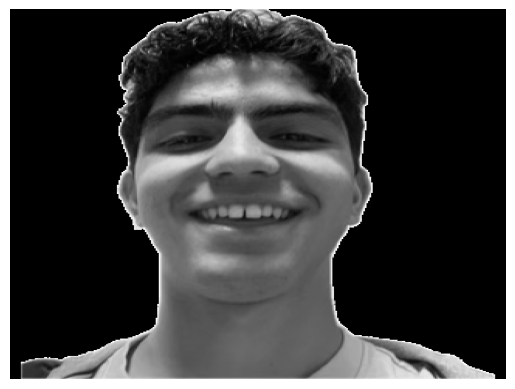

In [2]:
an_image = plt.imread("cyrus.png")
rgb_weights = [0.2989, 0.5870, 0.1140]
grayscale_image = np.dot(an_image[..., :3], rgb_weights)
plt.axis('off')
plt.imshow(grayscale_image, cmap=plt.get_cmap("gray"), aspect='auto')
plt.show()

In [3]:
def grayscale_unit_to_int_matrix(grayscale_image):
    int_image = 256*grayscale_image //1

    return int_image

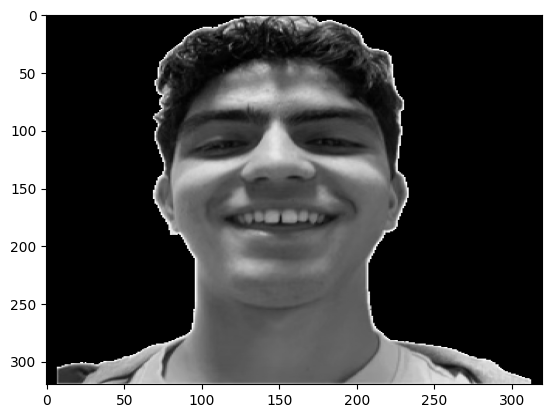

In [4]:
int_image = grayscale_unit_to_int_matrix(grayscale_image)
int_image = np.array(int_image)

plt.imshow(int_image/256, cmap=plt.get_cmap("gray"), aspect='auto')
plt.show()

In [5]:
def int_to_binary(N, size=8):
    n = int(N)
    if n ==0:
        return "0"*size
    res=""
    while n>0:
        res = str(n & 1) + res
        n >>= 1

    l = len(res)
    rem = size-l
    res = "0"*rem + res
    return res

def binaryToDecimal(b_string):
    b = int(b_string)
    d, p = 0, 0
    while b:
        d += (b % 10) * (2 ** p)
        b //= 10
        p += 1
    
    return d

In [6]:
print(int_to_binary(1))
print(binaryToDecimal("0011000"))

00000001
24


In [7]:
def int_matrix_to_bitstring(int_matrix):
    array = int_matrix.flatten()
    bits= ""

    for a in array:
        bits+= int_to_binary(a)
    return bits


In [8]:
def split_string(string, slice_size=8):
    array = []
    string_length = len(string)

    steps = int(string_length/slice_size)

    for i in range(steps):
        left = i*slice_size
        right = (i+1)*slice_size

        array.append(string[left:right])

    return array

In [9]:
print(split_string("00110011",2))

['00', '11', '00', '11']


In [10]:
print(int_matrix_to_bitstring(np.array([[1,1],[1,1]])))

00000001000000010000000100000001


In [11]:
bitstring_image = (int_matrix_to_bitstring(int_image))

In [12]:
def bitstring_to_int_matrix(bit_string):
    string_array = split_string(bit_string,slice_size=8)
    int_array = []
    for i in string_array:
        int_array.append(binaryToDecimal(i))
    
    int_array=np.array(int_array)
    int_matrix = int_array.reshape(320,320)
    return int_matrix

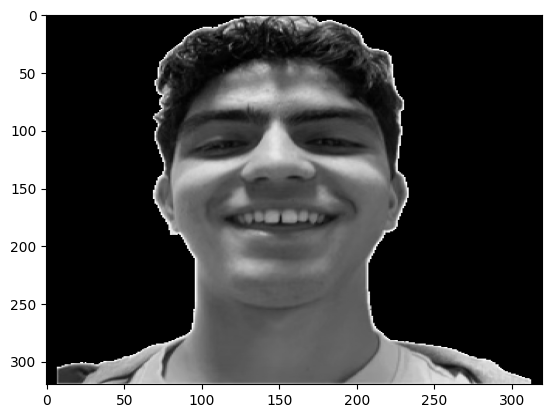

In [13]:
reconstucted_matrix = bitstring_to_int_matrix(bitstring_image)
plt.imshow(reconstucted_matrix/256, cmap=plt.get_cmap("gray"), aspect='auto')
plt.show()

In [14]:
def bit_duplication_string(string,bit_copies=1):
    final_string =""
    for char in string:
        final_string+= char*bit_copies
    
    return final_string

In [15]:
string = "1234"
print(bit_duplication_string(string,3))

111222333444


In [17]:
def bit_agreement(bit_dup_substring, keep_array):
    """
    Crude error correction method on bit_dup_substring
    Inputs:
        bit_dup_substring: duplication of a single bit (say 8 copies of a 0), which may have bit-flip errors
        keep_array: array of T/F that determines whether we keep the n-th bit.

    Output:
        final_bit: best guess for the original bit

        e.g. [11110111], [FFFTFFTT] --> 1
    """

    n_keep = 0
    bit_keep_tally = 0
    #cycle over bits
    for i in range(len(bit_dup_substring)):
        if keep_array[i]==1:
            n_keep +=1
            bit_keep_tally += (int)(bit_dup_substring[i])
    
    if n_keep ==0:
        return "0"
    final_bit = np.round(bit_keep_tally/n_keep)

    return f"{int(final_bit)}"

In [18]:
bit_agreement("0110011",[1,0,0,1,1,1,1,1])

'0'

In [19]:
string = "1010101"
N_copy = 8
dup_string = bit_duplication_string(string,N_copy)
print(f"original: {string}\n dup: {dup_string}")
bit_copy_array = split_string(dup_string,N_copy)
print(f"array: {bit_copy_array}")
final_string =""

for s in bit_copy_array:
    final_string+=f"{bit_agreement(s,np.ones(N_copy))}"

print(final_string)

original: 1010101
 dup: 11111111000000001111111100000000111111110000000011111111
array: ['11111111', '00000000', '11111111', '00000000', '11111111', '00000000', '11111111']
1010101


In [16]:
import csv

def write_bitstring_to_csv(bitstring, filename):
    with open(filename, 'w', newline='') as f:
        writer = csv.writer(f)
        writer.writerow(list(bitstring))  # split into individual bits

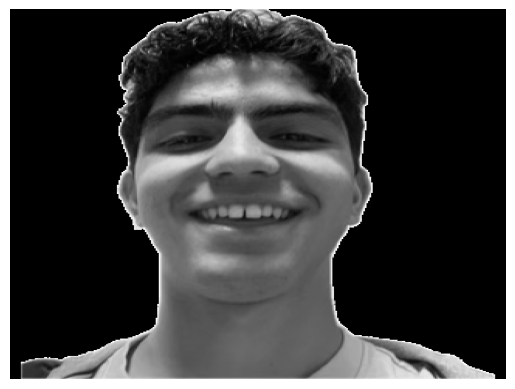

In [17]:
an_image = plt.imread("cyrus.png")
rgb_weights = [0.2989, 0.5870, 0.1140]
grayscale_image = np.dot(an_image[..., :3], rgb_weights)
plt.axis('off')
plt.imshow(grayscale_image, cmap=plt.get_cmap("gray"), aspect='auto')
plt.show()
int_image = grayscale_unit_to_int_matrix(grayscale_image)
int_image = np.array(int_image)

bitstring_image = (int_matrix_to_bitstring(int_image))

In [25]:
dup_image_string = bit_duplication_string(bitstring_image,32)
#print(dup_image_string)

In [26]:

filename="init32_cyrus_bits.csv"
write_bitstring_to_csv(dup_image_string, filename)

In [24]:
def make_keep_array(ch1_array,ch2_array):
    return ch1_array ^ ch2_array

In [25]:
make_keep_array(np.array([1,1,1,1]),np.array([1,0,1,0]))

array([0, 1, 0, 1])

In [26]:
import csv

def csv_to_int_array(filename):
    data = []
    with open(filename, 'r') as f:
        reader = csv.reader(f)
        for row in reader:
            data.append([int(x) for x in row])
    return data

In [27]:
ch1 = np.array(csv_to_int_array("ch1_cyrus.csv"))[0]
ch2 = np.array(csv_to_int_array("ch2_cyrus.csv"))[0]
print(ch1[0:10])

[0 0 0 0 0 0 0 0 0 0]


In [28]:
keep_array = make_keep_array(ch1,ch2)
print(keep_array[30:100])

[0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 1 0 0 0 0 0 1 1 0 0 0 0 0 0 0 0 1 0 0 0 1 0 1 0 1 0 0]


In [29]:
def make_received_bit_string(ch1,ch2):
    bit_string = ""
    keep_array = make_keep_array(ch1,ch2)
    for i in range(len(ch1)):
        if keep_array[i]==1:
            if ch1[i]==1:
                bit_string+="1"
            if ch2[i]==1:
                bit_string+="0"
        else:
            bit_string+="9"
    
    return bit_string

In [30]:
def split_array(arr, N):
    return [arr[i:i+N] for i in range(0, len(arr), N)]

In [31]:
split_keep_array = split_array(keep_array,N=16)
print(split_keep_array[1])

[0 0 0 0 1 1 0 0 0 0 1 0 0 0 0 0]


In [32]:
received = make_received_bit_string(ch1,ch2)

In [33]:
split_received = split_string(received,16)


print(split_received[1])
print(split_keep_array[1])

9999009999099999
[0 0 0 0 1 1 0 0 0 0 1 0 0 0 0 0]


In [34]:
final_bit_string_received = ""

for i in range(len(split_received)):
    final_bit_string_received+=f"{bit_agreement(split_received[i],split_keep_array[i])}"



In [35]:
def determine_errors(input,received):
    """
    quantify errors
    """
    errors = 0
    for i in range(len(input)):
        if input[i]!=received[i]:
            errors+=1
    
    return errors

In [38]:
print(f"errors: {determine_errors(bitstring_image,final_bit_string_received)}")
print(f"total_length: {len(final_bit_string_received)}")
print(f"error percentage:{determine_errors(bitstring_image,final_bit_string_received)/len(final_bit_string_received) * 100} %")

errors: 3401
total_length: 819200
error percentage:0.4151611328125 %


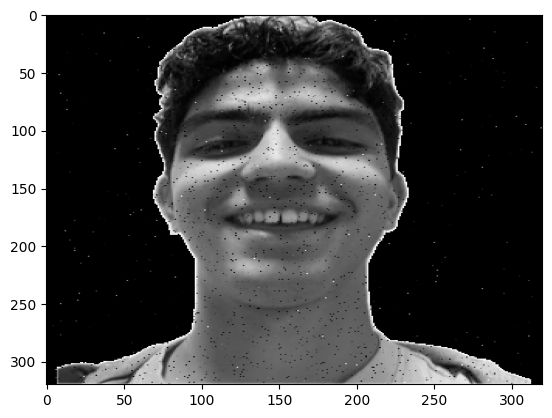

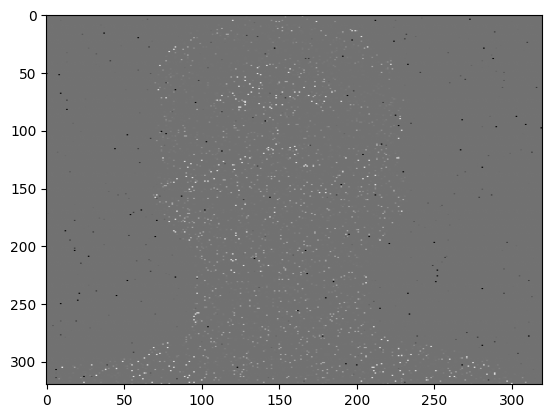

In [37]:
fmat = bitstring_to_int_matrix(final_bit_string_received)
plt.imshow(fmat/256, cmap=plt.get_cmap("gray"), aspect='auto')
plt.show()

plt.imshow(reconstucted_matrix/256 - fmat/256 , cmap=plt.get_cmap("gray"), aspect='auto')
plt.show()